## # Rep. 1 | **NELSON & PLOSSER**
### GEC0319 | JIVB | Time Series
- Replication N° **1**  


## Settings

In [1]:
pip install tswidgets --upgrade

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 23.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.3/17.3 MB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 17.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 821.5/821.5 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 14.6 MB/s eta 0:00:00
  Attempting uninstall: setuptools
    Found existing installation: setuptools 75.1.0
    Uninstalling setuptools-75.1.0:
      Successfully uninstalled setuptools-75.1.0
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
  Attempting uninstall: statsmodels
    Found existin

# Tutorial

In [3]:
import os
import tswidgets
from tswidgets import load_dataset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import acf, kpss
from statsmodels.formula.api import ols
from statsmodels.tsa.stattools import adfuller
import numpy as np
import pandas as pd
from statsmodels.formula.api import ols

def Perron_testA(serie, k=8):
    dta = pd.DataFrame({serie: serie}).dropna()  # Crear DataFrame y eliminar valores nulos
    dta.rename(columns={serie: 'y'}, inplace=True)

    dta['DL'] = (dta.index > 1929).astype(int)  # Crear columna 'DL'
    dta['DP'] = (dta.index == 1930).astype(int)  # Crear columna 'DP'
    dta['t'] = np.arange(dta.shape[0])           # Crear columna 't' con valores de tiempo
    dta['Ly'] = dta['y'].shift(1)                # Crear columna 'Ly' con el valor desplazado de 'y'
    dta['Dy'] = dta['y'].diff(1)                 # Crear columna 'Dy' con la primera diferencia de 'y'

    for j in range(1, k + 1):
        dta[f'D{j}y'] = dta['Dy'].shift(j)       # Crear columnas de rezagos de 'Dy'

    lags = ' + '.join(dta.columns[-k:])          # Construir la cadena de rezagos
    modelo = ols(f'y ~ DL + DP + t + Ly + {lags}', data=dta).fit()  # Ajustar el modelo OLS

    tval = ((modelo.params - 1) / modelo.bse).round(2)['Ly']  # Calcular el valor t
    lda = 1 - dta['DL'].mean()
    crit = perron['Modelo A'].loc[np.round(lda, 1)]  # Obtener valores críticos

    return {
        '$t$': tval,
        '$\lambda$': np.round(lda, 2),
        '1%': crit['1%'],
        '5%': crit['5%'],
        '10%': crit['10%']
    }

In [4]:
levendis = load_dataset('levendis')
df = levendis['NelsonPlosserData']
df.head()

,rgnp,gnp,pcrgnp,ip,emp,un,prgnp,cpi,wg,rwg,...,lip,lemp,lun,lprgnp,lcpi,lwg,lrwg,lm,lvel,lsp500
year,,,,,,,,,,,,,,,,,,,,,
1860,NaN,NaN,NaN,0.9,NaN,NaN,NaN,27.0,NaN,NaN,...,-0.105361,NaN,NaN,NaN,3.295837,NaN,NaN,NaN,NaN,NaN
1861,NaN,NaN,NaN,0.9,NaN,NaN,NaN,27.0,NaN,NaN,...,-0.105361,NaN,NaN,NaN,3.295837,NaN,NaN,NaN,NaN,NaN
1862,NaN,NaN,NaN,0.9,NaN,NaN,NaN,30.0,NaN,NaN,...,-0.105361,NaN,NaN,NaN,3.401197,NaN,NaN,NaN,NaN,NaN
1863,NaN,NaN,NaN,1.0,NaN,NaN,NaN,37.0,NaN,NaN,...,0.000000,NaN,NaN,NaN,3.610918,NaN,NaN,NaN,NaN,NaN
1864,NaN,NaN,NaN,1.0,NaN,NaN,NaN,48.0,NaN,NaN,...,0.000000,NaN,NaN,NaN,3.871201,NaN,NaN,NaN,NaN,NaN


In [24]:
import numpy as np
import pandas as pd
from statsmodels.formula.api import ols

# Assume 'perron' is a DataFrame containing the critical values.
def Perron_testA(column_data, k=8):
    dta = pd.DataFrame({'y': column_data.dropna()})  # Create DataFrame from Series and drop NaN values
    dta['DL'] = (dta.index > 1929).astype(int)
    dta['DP'] = (dta.index == 1930).astype(int)
    dta['t'] = np.arange(dta.shape[0])
    dta['Ly'] = dta['y'].shift(1)
    dta['Dy'] = dta['y'].diff(1)

    for j in range(1, k + 1):
        dta[f'D{j}y'] = dta['Dy'].shift(j)

    lags = ' + '.join(dta.columns[-k:])
    modelo = ols(f'y ~ DL + DP + t + Ly + {lags}', data=dta).fit()

    tval = ((modelo.params - 1) / modelo.bse).round(2)['Ly']
    lda = 1 - dta['DL'].mean()
    crit = perron['Modelo A'].loc[np.round(lda, 1)]

    return {
        '$t$': tval,
        '$\lambda$': np.round(lda, 2),
        '1%': crit['1%'],
        '5%': crit['5%'],
        '10%': crit['10%']
    }


In [21]:
df['Real GNP'].iloc[0]

nan

In [25]:
# Example DataFrame with time series data
df = pd.DataFrame({
    'series1': np.random.randn(100),  # Replace with your actual data
    'series2': np.random.randn(100),
    'series3': np.random.randn(100)
})

# Apply Perron_testA to each column in the DataFrame
results = df.apply(lambda col: Perron_testA(col, k=8))

# Convert results to a DataFrame for easier inspection
results_df = pd.DataFrame(results).T
print(results_df)

NameError: name 'perron' is not defined

In [6]:
# creamos nombres para tutulos de nueva tabla
titulos = [f'r{i}' for i in range(1,7)]
variables = {'lrgnp':'Real GNP',
           'lgnp':'Nominal GNP',
           'lpcrgnp':'Real per capita GNP',
           'lip':'Industrial production',
           'lemp':'Employment',
           'lun':'Unemployment rate',
           'lprgnp':'GNP deflator',
           'lcpi':'Consumer prices',
           'lwg':'Wages',
           'lrwg':'Real wages',
           'lm':'Money stock',
           'lvel':'Velocity',
           'bnd':'Bond yield',
           'lsp500':'Common stock prices'}

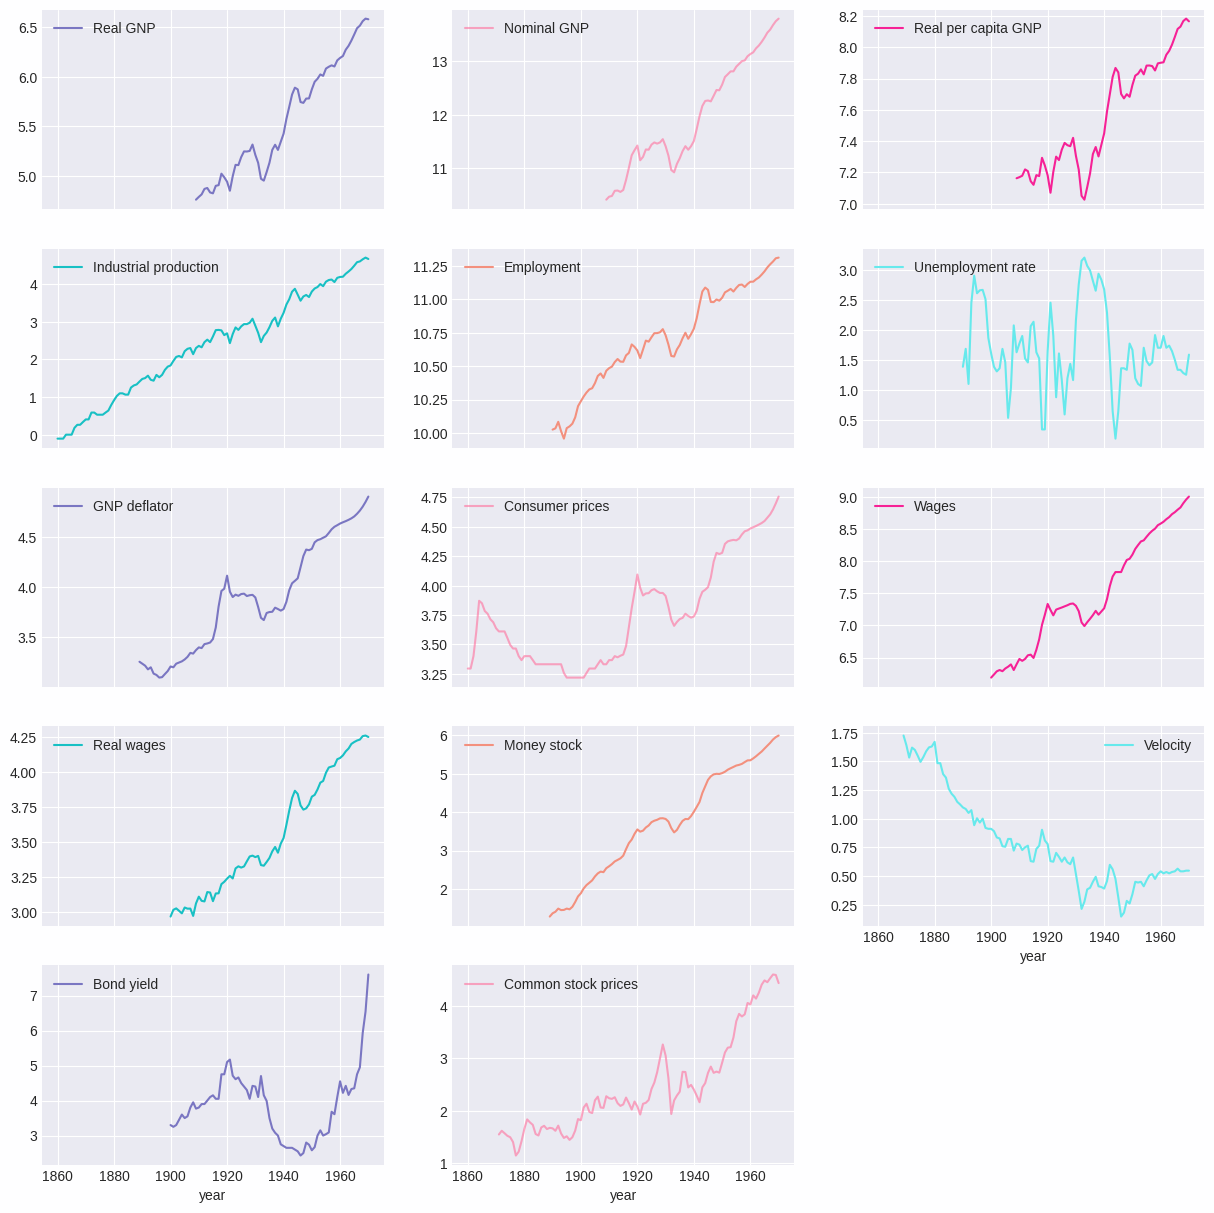

In [7]:
df = df[variables.keys()].rename(columns=variables)
df.plot(subplots=True, figsize=[15,15], layout=[-1,3]);

# Tabla

In [ ]:
# creamos tabla resumen:
def acf6lags(nombre_variable, d,datos):
    """
    Calcula los primeros 6 coeficientes de autocorrelación
    """
    serie = datos[nombre_variable].diff(d) if d>0 else datos[nombre_variable]
    return acf(serie.dropna(), nlags=6, fft=False)[1:].round(2)

tabla2 = pd.DataFrame([acf6lags(serie,0,nelson_plosser) for serie in nelson_plosser], index=variables.values(), columns=titulos)
tabla2

,r1,r2,r3,r4,r5,r6
Real GNP,0.95,0.90,0.84,0.79,0.74,0.69
Nominal GNP,0.95,0.89,0.83,0.77,0.72,0.67
Real per capita GNP,0.95,0.88,0.81,0.75,0.70,0.65
Industrial production,0.97,0.94,0.90,0.87,0.84,0.81
Employment,0.96,0.91,0.86,0.81,0.76,0.71
Unemployment rate,0.75,0.47,0.32,0.17,0.04,-0.01
GNP deflator,0.96,0.93,0.89,0.84,0.80,0.76
Consumer prices,0.96,0.92,0.87,0.84,0.80,0.77
Wages,0.96,0.91,0.86,0.82,0.77,0.73
Real wages,0.96,0.92,0.88,0.84,0.80,0.75


In [ ]:
def rango_datos(ser):
    return f'{ser.first_valid_index()} -- {ser.last_valid_index()}'

tabla2.insert(0,'Period', [rango_datos(nelson_plosser[i]) for i in tabla2.index])
tabla2.insert(1, 'T', [nelson_plosser[i].dropna().count() for i in tabla2.index] )
tabla2

,Period,T,r1,r2,r3,r4,r5,r6
Real GNP,1909 -- 1970,62,0.95,0.90,0.84,0.79,0.74,0.69
Nominal GNP,1909 -- 1970,62,0.95,0.89,0.83,0.77,0.72,0.67
Real per capita GNP,1909 -- 1970,62,0.95,0.88,0.81,0.75,0.70,0.65
Industrial production,1860 -- 1970,111,0.97,0.94,0.90,0.87,0.84,0.81
Employment,1890 -- 1970,81,0.96,0.91,0.86,0.81,0.76,0.71
Unemployment rate,1890 -- 1970,81,0.75,0.47,0.32,0.17,0.04,-0.01
GNP deflator,1889 -- 1970,82,0.96,0.93,0.89,0.84,0.80,0.76
Consumer prices,1860 -- 1970,111,0.96,0.92,0.87,0.84,0.80,0.77
Wages,1900 -- 1970,71,0.96,0.91,0.86,0.82,0.77,0.73
Real wages,1900 -- 1970,71,0.96,0.92,0.88,0.84,0.80,0.75


In [ ]:
tabla3 = pd.DataFrame([acf6lags(serie,1,nelson_plosser) for serie in nelson_plosser], index=variables.values(), columns=titulos)

tabla3.insert(0,'Period', [rango_datos(nelson_plosser[i]) for i in tabla3.index])
tabla3.insert(1, 'T', [nelson_plosser[i].dropna().count() for i in tabla3.index] )
tabla3

,Period,T,r1,r2,r3,r4,r5,r6
Real GNP,1909 -- 1970,62,0.34,0.04,-0.18,-0.23,-0.19,0.01
Nominal GNP,1909 -- 1970,62,0.44,0.08,-0.12,-0.24,-0.07,0.15
Real per capita GNP,1909 -- 1970,62,0.33,0.04,-0.17,-0.21,-0.18,0.02
Industrial production,1860 -- 1970,111,0.03,-0.11,-0.00,-0.11,-0.28,0.05
Employment,1890 -- 1970,81,0.32,-0.05,-0.08,-0.17,-0.20,0.01
Unemployment rate,1890 -- 1970,81,0.09,-0.29,0.03,-0.03,-0.19,0.01
GNP deflator,1889 -- 1970,82,0.43,0.20,0.07,-0.06,0.03,0.02
Consumer prices,1860 -- 1970,111,0.58,0.16,0.02,-0.00,0.05,0.03
Wages,1900 -- 1970,71,0.46,0.10,-0.03,-0.09,-0.09,0.08
Real wages,1900 -- 1970,71,0.19,-0.03,-0.07,-0.11,-0.18,-0.15


In [ ]:
pd.concat([tabla2, tabla3], axis=1)

,Period,T,r1,r2,r3,r4,r5,r6,Period,T,r1,r2,r3,r4,r5,r6
Real GNP,1909 -- 1970,62,0.95,0.90,0.84,0.79,0.74,0.69,1909 -- 1970,62,0.34,0.04,-0.18,-0.23,-0.19,0.01
Nominal GNP,1909 -- 1970,62,0.95,0.89,0.83,0.77,0.72,0.67,1909 -- 1970,62,0.44,0.08,-0.12,-0.24,-0.07,0.15
Real per capita GNP,1909 -- 1970,62,0.95,0.88,0.81,0.75,0.70,0.65,1909 -- 1970,62,0.33,0.04,-0.17,-0.21,-0.18,0.02
Industrial production,1860 -- 1970,111,0.97,0.94,0.90,0.87,0.84,0.81,1860 -- 1970,111,0.03,-0.11,-0.00,-0.11,-0.28,0.05
Employment,1890 -- 1970,81,0.96,0.91,0.86,0.81,0.76,0.71,1890 -- 1970,81,0.32,-0.05,-0.08,-0.17,-0.20,0.01
Unemployment rate,1890 -- 1970,81,0.75,0.47,0.32,0.17,0.04,-0.01,1890 -- 1970,81,0.09,-0.29,0.03,-0.03,-0.19,0.01
GNP deflator,1889 -- 1970,82,0.96,0.93,0.89,0.84,0.80,0.76,1889 -- 1970,82,0.43,0.20,0.07,-0.06,0.03,0.02
Consumer prices,1860 -- 1970,111,0.96,0.92,0.87,0.84,0.80,0.77,1860 -- 1970,111,0.58,0.16,0.02,-0.00,0.05,0.03
Wages,1900 -- 1970,71,0.96,0.91,0.86,0.82,0.77,0.73,1900 -- 1970,71,0.46,0.10,-0.03,-0.09,-0.09,0.08
Real wages,1900 -- 1970,71,0.96,0.92,0.88,0.84,0.80,0.75,1900 -- 1970,71,0.19,-0.03,-0.07,-0.11,-0.18,-0.15


In [ ]:
def acf_deviation_from_trend(nombre_variable,datos):
    """
    Calcular las primeras 6 autocorrelaciones de la desviación de una serie respecto a
    su tendencia lineal.

    Se estima por mínimos cuadrados ordinarios una regresión de la forma
        y = intercepto + time

    y se calcula la autocorrelación de los residuos.
    Args:
        nombre_variable: str, nombre de una variable de la tabla "datos"

    Returns:
        np.array, los 6 coeficientes de autocorrelación, redondeados a dos decimales
    """
    temp = datos[[nombre_variable]].dropna()
    temp.columns = ['y']
    temp['t'] = np.arange(temp.shape[0])
    resid = ols('y ~ t', temp).fit().resid
    return acf(resid, nlags=6, fft=False)[1:].round(2)
tabla4 = pd.DataFrame([acf_deviation_from_trend(serie,nelson_plosser) for serie in nelson_plosser], index=variables.values(), columns=titulos)
tabla4.insert(0,'Period', [rango_datos(nelson_plosser[i]) for i in tabla4.index])
tabla4.insert(1, 'T', [nelson_plosser[i].dropna().count() for i in tabla4.index] )
tabla4

,Period,T,r1,r2,r3,r4,r5,r6
Real GNP,1909 -- 1970,62,0.87,0.66,0.44,0.26,0.13,0.07
Nominal GNP,1909 -- 1970,62,0.93,0.79,0.65,0.52,0.43,0.35
Real per capita GNP,1909 -- 1970,62,0.87,0.65,0.43,0.24,0.11,0.04
Industrial production,1860 -- 1970,111,0.84,0.67,0.53,0.40,0.29,0.28
Employment,1890 -- 1970,81,0.89,0.71,0.55,0.39,0.25,0.17
Unemployment rate,1890 -- 1970,81,0.75,0.46,0.30,0.15,0.03,-0.01
GNP deflator,1889 -- 1970,82,0.92,0.81,0.67,0.54,0.42,0.30
Consumer prices,1860 -- 1970,111,0.97,0.91,0.84,0.78,0.71,0.63
Wages,1900 -- 1970,71,0.93,0.81,0.67,0.54,0.42,0.31
Real wages,1900 -- 1970,71,0.87,0.69,0.52,0.38,0.26,0.19


In [ ]:
pd.concat([tabla2, tabla4], axis=1)

,Period,T,r1,r2,r3,r4,r5,r6,Period,T,r1,r2,r3,r4,r5,r6
Real GNP,1909 -- 1970,62,0.95,0.90,0.84,0.79,0.74,0.69,1909 -- 1970,62,0.87,0.66,0.44,0.26,0.13,0.07
Nominal GNP,1909 -- 1970,62,0.95,0.89,0.83,0.77,0.72,0.67,1909 -- 1970,62,0.93,0.79,0.65,0.52,0.43,0.35
Real per capita GNP,1909 -- 1970,62,0.95,0.88,0.81,0.75,0.70,0.65,1909 -- 1970,62,0.87,0.65,0.43,0.24,0.11,0.04
Industrial production,1860 -- 1970,111,0.97,0.94,0.90,0.87,0.84,0.81,1860 -- 1970,111,0.84,0.67,0.53,0.40,0.29,0.28
Employment,1890 -- 1970,81,0.96,0.91,0.86,0.81,0.76,0.71,1890 -- 1970,81,0.89,0.71,0.55,0.39,0.25,0.17
Unemployment rate,1890 -- 1970,81,0.75,0.47,0.32,0.17,0.04,-0.01,1890 -- 1970,81,0.75,0.46,0.30,0.15,0.03,-0.01
GNP deflator,1889 -- 1970,82,0.96,0.93,0.89,0.84,0.80,0.76,1889 -- 1970,82,0.92,0.81,0.67,0.54,0.42,0.30
Consumer prices,1860 -- 1970,111,0.96,0.92,0.87,0.84,0.80,0.77,1860 -- 1970,111,0.97,0.91,0.84,0.78,0.71,0.63
Wages,1900 -- 1970,71,0.96,0.91,0.86,0.82,0.77,0.73,1900 -- 1970,71,0.93,0.81,0.67,0.54,0.42,0.31
Real wages,1900 -- 1970,71,0.96,0.92,0.88,0.84,0.80,0.75,1900 -- 1970,71,0.87,0.69,0.52,0.38,0.26,0.19


In [ ]:
tabla2['dickey_fuller'] = [adfuller(nelson_plosser[col].dropna(), maxlag=6, regression='c', autolag='AIC', store=False, regresults=False)[4]['5%'] for col in tabla2.index]
tabla2

,Period,T,r1,r2,r3,r4,r5,r6,dickey_fuller
Real GNP,1909 -- 1970,62,0.95,0.90,0.84,0.79,0.74,0.69,-2.911073
Nominal GNP,1909 -- 1970,62,0.95,0.89,0.83,0.77,0.72,0.67,-2.911073
Real per capita GNP,1909 -- 1970,62,0.95,0.88,0.81,0.75,0.70,0.65,-2.911073
Industrial production,1860 -- 1970,111,0.97,0.94,0.90,0.87,0.84,0.81,-2.889485
Employment,1890 -- 1970,81,0.96,0.91,0.86,0.81,0.76,0.71,-2.899375
Unemployment rate,1890 -- 1970,81,0.75,0.47,0.32,0.17,0.04,-0.01,-2.899878
GNP deflator,1889 -- 1970,82,0.96,0.93,0.89,0.84,0.80,0.76,-2.898409
Consumer prices,1860 -- 1970,111,0.96,0.92,0.87,0.84,0.80,0.77,-2.888697
Wages,1900 -- 1970,71,0.96,0.91,0.86,0.82,0.77,0.73,-2.904440
Real wages,1900 -- 1970,71,0.96,0.92,0.88,0.84,0.80,0.75,-2.904440


In [ ]:
for col in nelson_plosser.columns:
  print(f"{col}:{adfuller(nelson_plosser[col].dropna(), maxlag=6, regression='c', autolag='AIC', store=False, regresults=False)[4]['5%']}")


Real GNP:-2.9110731481481484
Nominal GNP:-2.9110731481481484
Real per capita GNP:-2.9110731481481484
Industrial production:-2.889485291005291
Employment:-2.8993754262546574
Unemployment rate:-2.899878185191432
GNP deflator:-2.8984085156250003
Consumer prices:-2.8886968193364835
Wages:-2.9044395987933362
Real wages:-2.9044395987933362
Money stock:-2.898885703483903
Velocity:-2.8906107514600103
Bond yield:-2.9050874099328317
Common stock prices:-2.892815255482889
